Figure S10: pcQTL discoveries by PC order. A The fraction of PC phenotypes across tissues with at least one significant QTL split into the primary (first) PC, the last PC, and all other PCs (middle). p-values are from a paired-sample t-test. B Distribution of the maximum PPH4 colocalization probability for each pcQTL credible set with any cluster eQTL credible set. Dotted line PPH4=0.75. C The fraction of PC phenotypes across tissues with at least one novel significant QTL split into the primary (first) PC, the last PC, and all other PCs (middle). p-values are from a paired-sample t-test.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import upsetplot as up
from scipy.stats import spearmanr, ttest_ind, ttest_rel, norm
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import ast
import pyranges as pr



from tqdm.auto import tqdm 
tqdm.pandas()

prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append('/home/klawren/oak/pcqtls/workflow/scripts')
from utils import *
from annotate_clusters import * 
import call_clusters



%config InlineBackend.figure_formats = ['png']
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

/home/klawren/.pixi/envs/python/lib/python3.12/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
susie_annotated = load_across_tissues(config, load_susie_annotated)
pcs = load_across_tissues(config, load_pc)

In [ ]:
pcs['phenotype_id'] = pcs['gene_id']
annotate_pc_order(pcs)

susie_annotated['phenotype_id_tissue'] = susie_annotated['phenotype_id'] + '-' + susie_annotated['tissue_id']
pcs['phenotype_id_tissue'] = pcs['phenotype_id'] + '-' + pcs['tissue_id']
pcs['has_cs'] = pcs['phenotype_id_tissue'].isin(susie_annotated['phenotype_id_tissue'])

# fraction phenotypes of each type that have a credible set
pc_cs_by_order = pcs.groupby(['tissue_id', 'pc_order']).agg({'has_cs':'mean'}).reset_index()

/local/scratch/klawren/slrmtmp.48343185/ipykernel_21200/2439975531.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcs['phenotype_id'] = pcs['gene_id']
/home/klawren/oak/pcqtls/workflow/scripts/notebook_helper_functions.py:261: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pc_df['pc_num'] = pc_df['phenotype_id'].str.split('_pc').str[-1].astype(int)
/home/klawren/oak/pcqtls/workflow/scripts/notebook_helper_functions.py:265: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inser

/local/scratch/klawren/slrmtmp.48323884/ipykernel_16676/4292245301.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(pc_cs_by_order, x='pc_order', y='has_cs', ax=ax, palette=sns.color_palette('light:{}_r'.format(qtl_palette['pcQTL only']), n_colors=4), order=['first', 'middle', 'last'])
/local/scratch/klawren/slrmtmp.48323884/ipykernel_16676/4292245301.py:4: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(pc_cs_by_order, x='pc_order', y='has_cs', ax=ax, palette=sns.color_palette('light:{}_r'.format(qtl_palette['pcQTL only']), n_colors=4), order=['first', 'middle', 'last'])


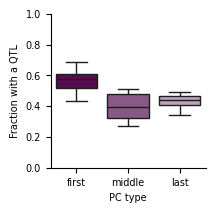

In [ ]:
fig, ax = plt.subplots(figsize=(2,2))

#sns.swarmplot(pc_cs_by_order, x='pc_order', y='has_cs', ax=ax, color='k', order=['first', 'middle', 'last'])
sns.boxplot(pc_cs_by_order, x='pc_order', y='has_cs', ax=ax, palette=sns.color_palette('light:{}_r'.format(qtl_palette['pcQTL only']), n_colors=4), order=['first', 'middle', 'last'])
ax.set_ylim([0,1])

ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('PC type')
ax.set_ylabel('Fraction with a QTL')

plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s8_a.pdf", transparent=True)
plt.show()


In [ ]:
for order_1, order_2 in [['first', 'middle'], ['first', 'last'], ['middle', 'last']]:
    print('{}-{}'.format(order_1, order_2))
    print(ttest_rel(pc_cs_by_order[pc_cs_by_order['pc_order']==order_2]['has_cs'], pc_cs_by_order[pc_cs_by_order['pc_order']==order_1]['has_cs']))

first-middle
TtestResult(statistic=-6.865197382979757, pvalue=1.734416215599014e-05, df=12)
first-last
TtestResult(statistic=-11.466396331836398, pvalue=8.014127744739391e-08, df=12)
middle-last
TtestResult(statistic=1.5219774879095311, pvalue=0.15392111719290588, df=12)


In [5]:
pair_coloc = load_across_tissues(config, load_pairwise_coloc)

In [ ]:
pair_coloc['qtl1_id_tissue'] = pair_coloc['qtl1_id'] + '-' + pair_coloc['tissue_id']
pair_coloc['qtl2_id_tissue'] = pair_coloc['qtl2_id'] + '-' + pair_coloc['tissue_id']

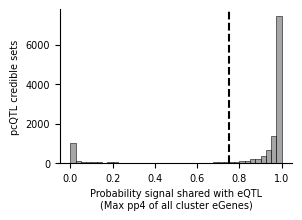

In [ ]:
fig, ax = plt.subplots(figsize=(3,2))

pc_coloc_with_any_e = pair_coloc[(pair_coloc['qtl1_id_tissue'].str.contains('_e_'))&(pair_coloc['qtl2_id_tissue'].str.contains('_pc'))].groupby('qtl2_id_tissue').agg({'PP.H4.abf':max}).reset_index()

sns.histplot(pc_coloc_with_any_e, x='PP.H4.abf', multiple='dodge', bins=40, ax=ax,
             common_norm=False, color='grey', alpha=.7)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('pcQTL credible sets')
ax.set_xlabel('Probability signal shared with eQTL\n(Max pp4 of all cluster eGenes)')

ax.axvline(.75, color='k', ls='--')
plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s8_b.pdf", transparent=True)
plt.show()

In [6]:
underlying_signals = load_across_tissues(config, load_signal_groups)

In [21]:
underlying_signals['cs_id'] = underlying_signals['signal_id'].str.split('-')
underlying_signals_explode = underlying_signals.explode('cs_id')
underlying_signals_explode['phenotype_id_tissue'] = underlying_signals_explode['cs_id'].str.split('_cs').str[0] + '-' + underlying_signals['tissue_id']
# the ones with no e colocs
pcs['has_novel_cs'] = pcs['phenotype_id_tissue'].isin(underlying_signals_explode[underlying_signals_explode['num_e_coloc']==0]['phenotype_id_tissue'])
novel_cs_by_order = pcs.groupby(['tissue_id', 'pc_order']).agg({'has_novel_cs':'mean'}).reset_index()

/local/scratch/klawren/slrmtmp.48343185/ipykernel_50921/166711018.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcs['has_novel_cs'] = pcs['phenotype_id_tissue'].isin(underlying_signals_explode[underlying_signals_explode['num_e_coloc']==0]['phenotype_id_tissue'])


/local/scratch/klawren/slrmtmp.48343185/ipykernel_50921/4232446828.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(novel_cs_by_order, x='pc_order', y='has_novel_cs', ax=ax, palette=sns.color_palette('light:{}_r'.format(qtl_palette['pcQTL only']), n_colors=4), order=['first', 'middle', 'last'])
/local/scratch/klawren/slrmtmp.48343185/ipykernel_50921/4232446828.py:4: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(novel_cs_by_order, x='pc_order', y='has_novel_cs', ax=ax, palette=sns.color_palette('light:{}_r'.format(qtl_palette['pcQTL only']), n_colors=4), order=['first', 'middle', 'last'])


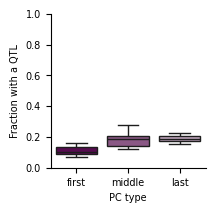

In [ ]:
fig, ax = plt.subplots(figsize=(2,2))

#sns.swarmplot(novel_cs_by_order, x='pc_order', y='has_novel_cs', ax=ax, color='k', order=['first', 'middle', 'last'], s=4, alpha=.5)
sns.boxplot(novel_cs_by_order, x='pc_order', y='has_novel_cs', ax=ax, palette=sns.color_palette('light:{}_r'.format(qtl_palette['pcQTL only']), n_colors=4), order=['first', 'middle', 'last'])
ax.set_ylim([0,1])

ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('PC type')
ax.set_ylabel('Fraction with a QTL')

plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s8_c.pdf", transparent=True)
plt.show()


In [23]:
for order_1, order_2 in [['first', 'middle'], ['first', 'last'], ['middle', 'last']]:
    print('{}-{}'.format(order_1, order_2))
    print(ttest_rel(novel_cs_by_order[novel_cs_by_order['pc_order']==order_2]['has_novel_cs'], novel_cs_by_order[novel_cs_by_order['pc_order']==order_1]['has_novel_cs']))

first-middle
TtestResult(statistic=6.3223493380873155, pvalue=3.8182584504702764e-05, df=12)
first-last
TtestResult(statistic=24.37486148132822, pvalue=1.3699529746837799e-11, df=12)
middle-last
TtestResult(statistic=0.836193831413932, pvalue=0.41938554642820036, df=12)
